# Sentimen Analisis Roblox

### Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import warnings
warnings.filterwarnings('ignore')

### Load Dataset

In [2]:
df = pd.read_csv('reviews_roblox.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (10000, 11)


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,498f037a-ce26-4f8f-bd27-bc0479785862,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,seru banget Roblox,5,0,2.716.875,2026-04-19 07:57:10,NaN,NaN,2.716.875
1,1e238c4d-14fb-4b88-a18b-8222e7bad80f,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,bagus banget tapi aturan ny bikin aku kesel di...,3,0,NaN,2026-04-19 07:55:09,NaN,NaN,NaN
2,b528e8be-0771-4103-99c6-95cdb1a32dcc,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,pelatihan ini anak pentingg iya nih Roblox,5,0,2.696.799,2026-04-19 07:55:07,NaN,NaN,2.696.799
3,ed08d7f1-41f7-4007-9936-326c1d902eb4,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,saya sangat senang bermain roblok,5,0,NaN,2026-04-19 07:54:29,NaN,NaN,NaN
4,fc03bd07-9902-43f1-ac5a-dcddd4fe2017,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,game nya bagus,5,0,2.715.1115,2026-04-19 07:52:06,NaN,NaN,2.715.1115


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   reviewId              10000 non-null  object 
 1   userName              10000 non-null  object 
 2   userImage             10000 non-null  object 
 3   content               9996 non-null   object 
 4   score                 10000 non-null  int64  
 5   thumbsUpCount         10000 non-null  int64  
 6   reviewCreatedVersion  7290 non-null   object 
 7   at                    10000 non-null  object 
 8   replyContent          0 non-null      float64
 9   repliedAt             0 non-null      float64
 10  appVersion            7290 non-null   object 
dtypes: float64(2), int64(2), object(7)
memory usage: 859.5+ KB


In [4]:
print(df.isna().sum())

reviewId                    0
userName                    0
userImage                   0
content                     4
score                       0
thumbsUpCount               0
reviewCreatedVersion     2710
at                          0
replyContent            10000
repliedAt               10000
appVersion               2710
dtype: int64


In [5]:
df = df.drop(columns=['reviewId', 'userImage', 'thumbsUpCount', 'reviewCreatedVersion',
                       'replyContent', 'repliedAt', 'appVersion', 'userName', 'at'])
df = df.dropna(subset=['content'])
df = df.reset_index(drop=True)
print(f'Shape setelah pembersihan kolom: {df.shape}')
df.head()

Shape setelah pembersihan kolom: (9996, 2)


,content,score
0,seru banget Roblox,5
1,bagus banget tapi aturan ny bikin aku kesel di...,3
2,pelatihan ini anak pentingg iya nih Roblox,5
3,saya sangat senang bermain roblok,5
4,game nya bagus,5


### Labeling

In [6]:
df['score'].value_counts()

,count
score,
5,6010
1,1993
4,947
3,629
2,417


In [7]:
def beri_label(score):
    if score >= 4:
        return 'positif'
    elif score == 3:
        return 'netral'
    else:
        return 'negatif'

def beri_label_num(score):
    if score >= 4:
        return 1
    elif score == 3:
        return 0
    else:
        return -1

df['label'] = df['score'].apply(beri_label)
df['label_num'] = df['score'].apply(beri_label_num)
df.head()

,content,score,label,label_num
0,seru banget Roblox,5,positif,1
1,bagus banget tapi aturan ny bikin aku kesel di...,3,netral,0
2,pelatihan ini anak pentingg iya nih Roblox,5,positif,1
3,saya sangat senang bermain roblok,5,positif,1
4,game nya bagus,5,positif,1


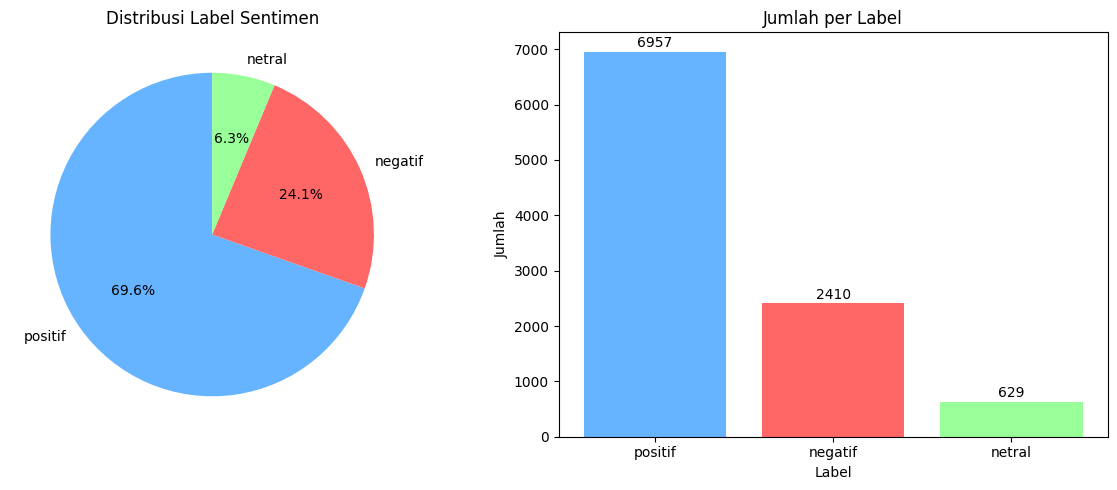

In [8]:
label_counts = df['label'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].pie(label_counts, labels=label_counts.index, autopct='%1.1f%%',
            startangle=90, colors=['#66b3ff', '#ff6666', '#99ff99'])
axes[0].set_title('Distribusi Label Sentimen')

bars = axes[1].bar(label_counts.index, label_counts.values,
                   color=['#66b3ff', '#ff6666', '#99ff99'])
for bar, val in zip(bars, label_counts.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
                 str(val), ha='center', va='bottom')
axes[1].set_title('Jumlah per Label')
axes[1].set_xlabel('Label')
axes[1].set_ylabel('Jumlah')

plt.tight_layout()
plt.show()

### Preprocessing

In [9]:
%pip install nltk Sastrawi -q

import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 9.1 MB/s eta 0:00:00


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [10]:
from tqdm import tqdm
tqdm.pandas()

In [11]:
# Cleaning
def preprocess_text(text):
    text = re.sub(r'https\S+', ' ', str(text), flags=re.IGNORECASE)
    text = text.lower()
    text = re.sub(r'@\S+', ' ', text, flags=re.IGNORECASE)
    text = re.sub(r'#\S+', ' ', text, flags=re.IGNORECASE)
    text = re.sub(r"'\w+", ' ', text)
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\d+', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['text_clean'] = df['content'].progress_apply(preprocess_text)
df[['content', 'text_clean']].head()

100%|██████████| 9996/9996 [00:00<00:00, 17586.47it/s]


,content,text_clean
0,seru banget Roblox,seru banget roblox
1,bagus banget tapi aturan ny bikin aku kesel di...,bagus banget tapi aturan ny bikin aku kesel dikit
2,pelatihan ini anak pentingg iya nih Roblox,pelatihan ini anak pentingg iya nih roblox
3,saya sangat senang bermain roblok,saya sangat senang bermain roblok
4,game nya bagus,game nya bagus


In [13]:
# Normalisasi slang
kamus_slang = pd.read_excel('kamuskatabaku.xlsx')
slang_dict = dict(zip(kamus_slang['tidak_baku'], kamus_slang['kata_baku']))

def ganti_slang(text):
    return ' '.join([slang_dict.get(kata, kata) for kata in text.split()])

df['text_normalized'] = df['text_clean'].progress_apply(ganti_slang)
df[['text_clean', 'text_normalized']].head()

100%|██████████| 9996/9996 [00:00<00:00, 111401.73it/s]


,text_clean,text_normalized
0,seru banget roblox,seru banget roblox
1,bagus banget tapi aturan ny bikin aku kesel dikit,bagus banget tapi aturan nya bikin aku kesel d...
2,pelatihan ini anak pentingg iya nih roblox,pelatihan ini anak penting iya nih roblox
3,saya sangat senang bermain roblok,saya sangat senang bermain roblok
4,game nya bagus,game ya bagus


In [14]:
# Stopword removal
from nltk.corpus import stopwords

stop_words = set(stopwords.words('indonesian'))

df['text_stopword'] = df['text_normalized'].progress_apply(
    lambda x: ' '.join([w for w in x.split() if w not in stop_words])
)
df[['text_normalized', 'text_stopword']].head()

100%|██████████| 9996/9996 [00:00<00:00, 118169.06it/s]


,text_normalized,text_stopword
0,seru banget roblox,seru banget roblox
1,bagus banget tapi aturan nya bikin aku kesel d...,bagus banget aturan nya bikin kesel dikit
2,pelatihan ini anak penting iya nih roblox,pelatihan anak iya nih roblox
3,saya sangat senang bermain roblok,senang bermain roblok
4,game ya bagus,game ya bagus


In [15]:
# Tokenisasi
from nltk.tokenize import RegexpTokenizer

regexp = RegexpTokenizer(r'\w+')
df['text_token'] = df['text_stopword'].progress_apply(regexp.tokenize)
df[['text_stopword', 'text_token']].head()

100%|██████████| 9996/9996 [00:00<00:00, 71233.99it/s]


,text_stopword,text_token
0,seru banget roblox,"[seru, banget, roblox]"
1,bagus banget aturan nya bikin kesel dikit,"[bagus, banget, aturan, nya, bikin, kesel, dikit]"
2,pelatihan anak iya nih roblox,"[pelatihan, anak, iya, nih, roblox]"
3,senang bermain roblok,"[senang, bermain, roblok]"
4,game ya bagus,"[game, ya, bagus]"


In [16]:
# Stemming
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

factory = StemmerFactory()
stemmer = factory.create_stemmer()

df['text_stem'] = df['text_token'].progress_apply(lambda x: [stemmer.stem(w) for w in x])
df['text_final'] = df['text_stem'].progress_apply(lambda x: ' '.join([w for w in x if len(w) > 2]))
df[['text_token', 'text_final']].head()

100%|██████████| 9996/9996 [00:00<00:00, 609854.29it/s]


,text_token,text_final
0,"[seru, banget, roblox]",seru banget roblox
1,"[bagus, banget, aturan, nya, bikin, kesel, dikit]",bagus banget atur nya bikin kesel dikit
2,"[pelatihan, anak, iya, nih, roblox]",latih anak iya nih roblox
3,"[senang, bermain, roblok]",senang main roblok
4,"[game, ya, bagus]",game bagus


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9996 entries, 0 to 9995
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   content          9996 non-null   object
 1   score            9996 non-null   int64 
 2   label            9996 non-null   object
 3   label_num        9996 non-null   int64 
 4   text_clean       9996 non-null   object
 5   text_normalized  9996 non-null   object
 6   text_stopword    9996 non-null   object
 7   text_token       9996 non-null   object
 8   text_stem        9996 non-null   object
 9   text_final       9996 non-null   object
dtypes: int64(2), object(8)
memory usage: 781.1+ KB


### EDA & Visualisasi

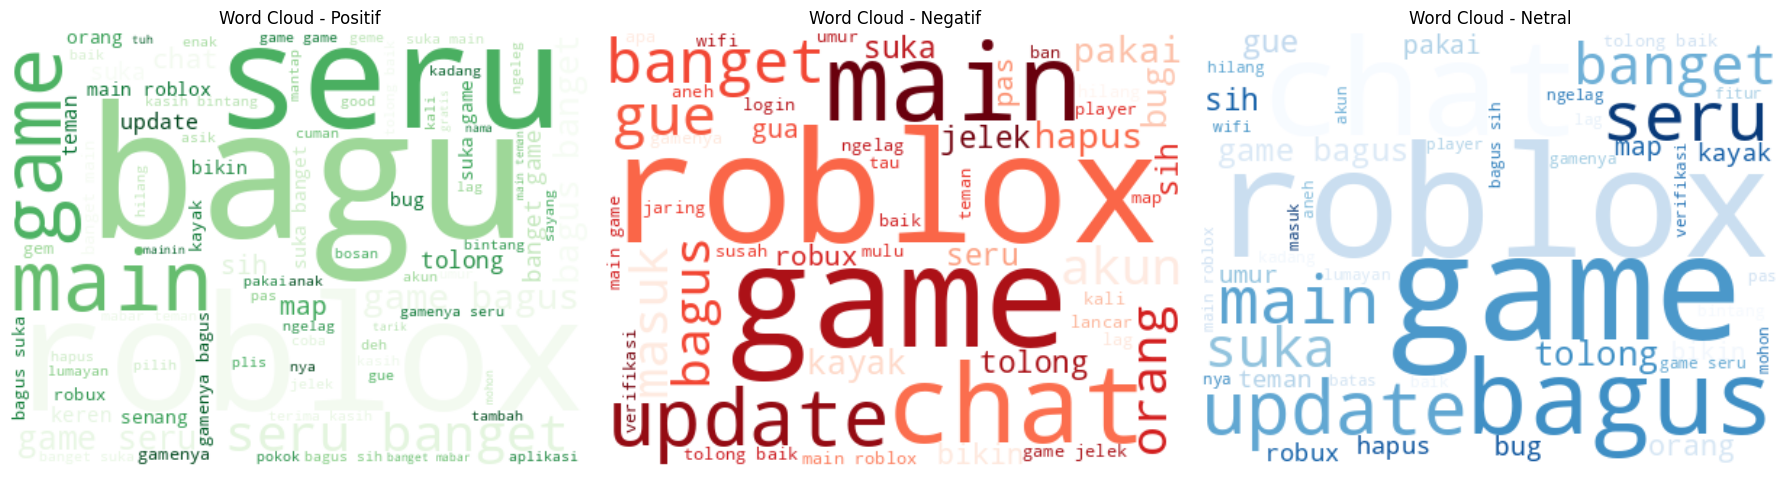

In [18]:
from wordcloud import WordCloud

sentimen_list = ['positif', 'negatif', 'netral']
colors = {'positif': 'Greens', 'negatif': 'Reds', 'netral': 'Blues'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, label in zip(axes, sentimen_list):
    text = ' '.join(df[df['label'] == label]['text_final'].tolist())
    wc = WordCloud(width=400, height=300, background_color='white',
                   colormap=colors[label], min_font_size=8).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'Word Cloud - {label.capitalize()}')
    ax.axis('off')

plt.tight_layout()
plt.show()

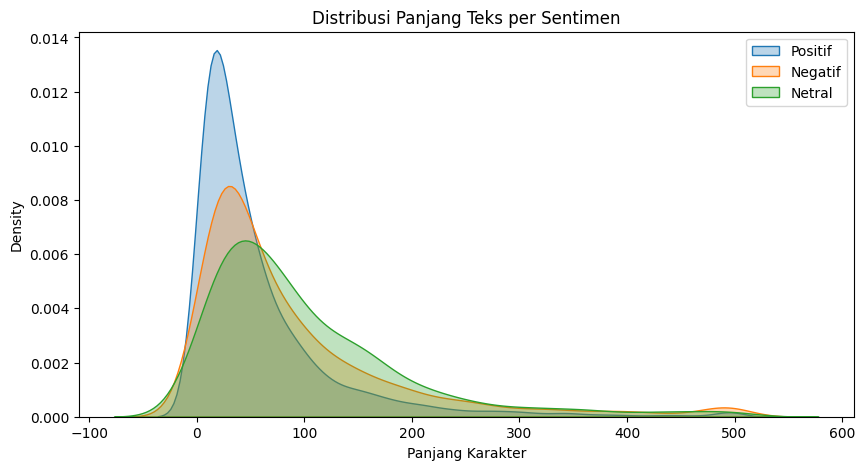

In [19]:
df['panjang_teks'] = df['content'].apply(len)

plt.figure(figsize=(10, 5))
for label in sentimen_list:
    subset = df[df['label'] == label]['panjang_teks']
    sns.kdeplot(subset, label=label.capitalize(), fill=True, alpha=0.3)

plt.title('Distribusi Panjang Teks per Sentimen')
plt.xlabel('Panjang Karakter')
plt.ylabel('Density')
plt.legend()
plt.show()

### Ekstraksi Fitur & Split Data

In [20]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_WORDS = 10000
MAX_LEN   = 100

tokenizer_dl = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer_dl.fit_on_texts(df['text_final'])

X_seq = tokenizer_dl.texts_to_sequences(df['text_final'])
X_pad = pad_sequences(X_seq, maxlen=MAX_LEN, padding='post', truncating='post')

y = df['label_num'].values

X_train_dl, X_test_dl, y_train_dl, y_test_dl = train_test_split(
    X_pad, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train_dl.shape}, Test: {X_test_dl.shape}')

Train: (7996, 100), Test: (2000, 100)


### Modeling

#### CNN + LSTM

In [23]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Embedding, Conv1D, MaxPooling1D,
                                      LSTM, Dense, Dropout, BatchNormalization)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

# label shift: -1,0,1 → 0,1,2
y_train_cat = to_categorical(y_train_dl + 1, num_classes=3)
y_test_cat  = to_categorical(y_test_dl  + 1, num_classes=3)

model_cnn_lstm = Sequential([
    Embedding(input_dim=MAX_WORDS, output_dim=128, input_length=MAX_LEN),
    Conv1D(128, kernel_size=5, activation='relu'),
    MaxPooling1D(pool_size=2),
    LSTM(64, dropout=0.3, recurrent_dropout=0.3),
    BatchNormalization(),
    Dense(64, activation='relu'),
    Dropout(0.4),
    Dense(3, activation='softmax')
])

model_cnn_lstm.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_cnn_lstm.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [24]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)
]

history_cnn = model_cnn_lstm.fit(
    X_train_dl, y_train_cat,
    epochs=20,
    batch_size=64,
    validation_data=(X_test_dl, y_test_cat),
    callbacks=callbacks
)

Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 32s 187ms/step - accuracy: 0.6537 - loss: 0.8576 - val_accuracy: 0.6960 - val_loss: 0.9001 - learning_rate: 0.0010
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 22s 179ms/step - accuracy: 0.6960 - loss: 0.7942 - val_accuracy: 0.6960 - val_loss: 0.8270 - learning_rate: 0.0010
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 41s 177ms/step - accuracy: 0.6960 - loss: 0.7880 - val_accuracy: 0.6960 - val_loss: 0.7740 - learning_rate: 0.0010
Epoch 4/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 22s 175ms/step - accuracy: 0.6960 - loss: 0.7792 - val_accuracy: 0.6960 - val_loss: 0.7699 - learning_rate: 0.0010
Epoch 5/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 21s 168ms/step - accuracy: 0.6990 - loss: 0.7404 - val_accuracy: 0.6980 - val_loss: 0.6933 - learning_rate: 0.0010
Epoch 6/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 22s 176ms/step - accuracy: 0.7603 - loss: 0.6319 - val_accuracy: 0.7890 - val_loss: 0.5626 - learning_rate: 0.0010
Epoch 7/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 40s 167ms/step - accuracy: 0.8

In [25]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_train_pred_cnn = np.argmax(model_cnn_lstm.predict(X_train_dl), axis=1) - 1
y_test_pred_cnn  = np.argmax(model_cnn_lstm.predict(X_test_dl),  axis=1) - 1

train_acc_cnn = accuracy_score(y_train_dl, y_train_pred_cnn)
test_acc_cnn  = accuracy_score(y_test_dl,  y_test_pred_cnn)

print(f'CNN+LSTM Train Accuracy: {train_acc_cnn:.4f}')
print(f'CNN+LSTM Test Accuracy : {test_acc_cnn:.4f}')
print()
print(classification_report(y_test_dl, y_test_pred_cnn,
                             target_names=['negatif', 'netral', 'positif']))

250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step
CNN+LSTM Train Accuracy: 0.8478
CNN+LSTM Test Accuracy : 0.8130

              precision    recall  f1-score   support

     negatif       0.64      0.78      0.70       482
      netral       0.00      0.00      0.00       126
     positif       0.88      0.90      0.89      1392

    accuracy                           0.81      2000
   macro avg       0.51      0.56      0.53      2000
weighted avg       0.77      0.81      0.79      2000



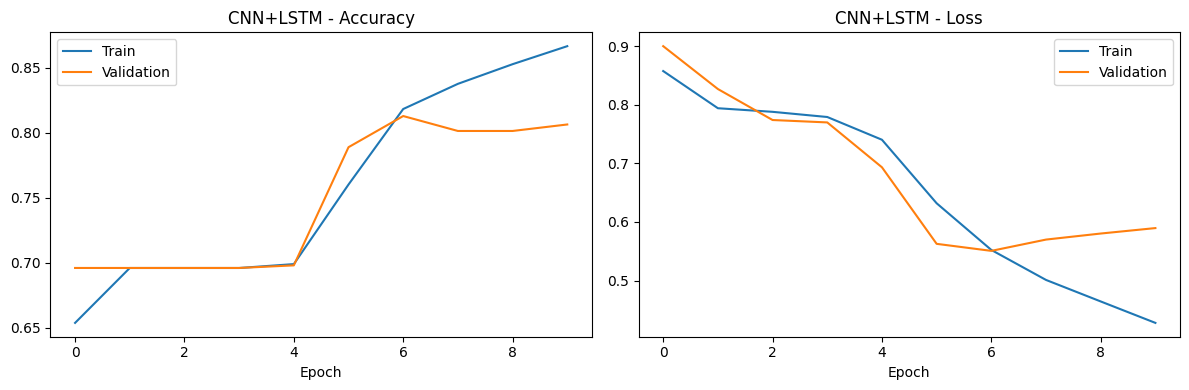

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_cnn.history['accuracy'],     label='Train')
axes[0].plot(history_cnn.history['val_accuracy'], label='Validation')
axes[0].set_title('CNN+LSTM - Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history_cnn.history['loss'],     label='Train')
axes[1].plot(history_cnn.history['val_loss'], label='Validation')
axes[1].set_title('CNN+LSTM - Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

In [27]:
model_cnn_lstm.save('model_cnn_lstm.h5')
print('Model CNN+LSTM disimpan.')

Model CNN+LSTM disimpan.


#### Bidirectional LSTM (RNN)

In [28]:
from tensorflow.keras.layers import Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

model_rnn = Sequential([
    Embedding(input_dim=MAX_WORDS, output_dim=128, input_length=MAX_LEN),
    Bidirectional(LSTM(64, return_sequences=True, dropout=0.3, recurrent_dropout=0.3)),
    Bidirectional(LSTM(32, dropout=0.3, recurrent_dropout=0.3)),
    Dense(64, activation='relu', kernel_regularizer=l2(0.01)),
    Dropout(0.4),
    Dense(3, activation='softmax')
])

model_rnn.compile(optimizer=Adam(learning_rate=0.001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
model_rnn.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [29]:
history_rnn = model_rnn.fit(
    X_train_dl, y_train_cat,
    epochs=20,
    batch_size=64,
    validation_data=(X_test_dl, y_test_cat),
    callbacks=callbacks
)

Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 90s 595ms/step - accuracy: 0.7214 - loss: 1.0742 - val_accuracy: 0.8030 - val_loss: 0.7170 - learning_rate: 0.0010
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 71s 566ms/step - accuracy: 0.8179 - loss: 0.6337 - val_accuracy: 0.8110 - val_loss: 0.5699 - learning_rate: 0.0010
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 79s 546ms/step - accuracy: 0.8463 - loss: 0.5125 - val_accuracy: 0.8050 - val_loss: 0.5543 - learning_rate: 5.0000e-04


In [30]:
y_train_pred_rnn = np.argmax(model_rnn.predict(X_train_dl), axis=1) - 1
y_test_pred_rnn  = np.argmax(model_rnn.predict(X_test_dl),  axis=1) - 1

train_acc_rnn = accuracy_score(y_train_dl, y_train_pred_rnn)
test_acc_rnn  = accuracy_score(y_test_dl,  y_test_pred_rnn)

print(f'Bi-LSTM Train Accuracy: {train_acc_rnn:.4f}')
print(f'Bi-LSTM Test Accuracy : {test_acc_rnn:.4f}')
print()
print(classification_report(y_test_dl, y_test_pred_rnn,
                             target_names=['negatif', 'netral', 'positif']))

250/250 ━━━━━━━━━━━━━━━━━━━━ 25s 93ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 127ms/step
Bi-LSTM Train Accuracy: 0.8133
Bi-LSTM Test Accuracy : 0.8030

              precision    recall  f1-score   support

     negatif       0.64      0.73      0.68       482
      netral       0.00      0.00      0.00       126
     positif       0.87      0.90      0.88      1392

    accuracy                           0.80      2000
   macro avg       0.50      0.54      0.52      2000
weighted avg       0.76      0.80      0.78      2000



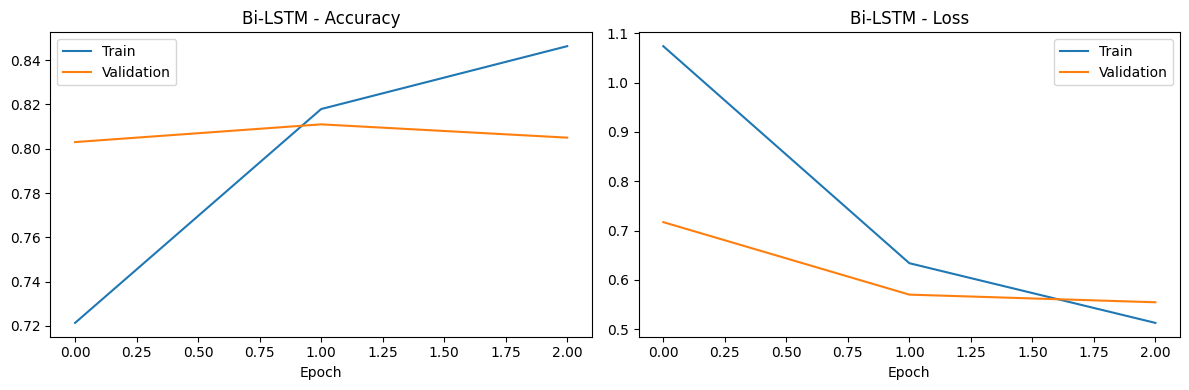

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_rnn.history['accuracy'],     label='Train')
axes[0].plot(history_rnn.history['val_accuracy'], label='Validation')
axes[0].set_title('Bi-LSTM - Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history_rnn.history['loss'],     label='Train')
axes[1].plot(history_rnn.history['val_loss'], label='Validation')
axes[1].set_title('Bi-LSTM - Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

In [32]:
model_rnn.save('model_rnn.h5')
print('Model Bi-LSTM disimpan.')

Model Bi-LSTM disimpan.


### Skema Pelatihan

#### Skema 1: SVM + TF-IDF (80/20)

In [33]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC

tfidf_s1 = TfidfVectorizer(max_features=10000, ngram_range=(1, 3), sublinear_tf=True)
X_tfidf_s1 = tfidf_s1.fit_transform(df['text_final'])

X_tr1, X_te1, y_tr1, y_te1 = train_test_split(
    X_tfidf_s1, df['label_num'], test_size=0.2, random_state=42, stratify=df['label_num']
)

svm_s1 = SVC(kernel='rbf', C=3.0, gamma='scale')
svm_s1.fit(X_tr1, y_tr1)

acc_train_s1 = accuracy_score(y_tr1, svm_s1.predict(X_tr1))
acc_test_s1  = accuracy_score(y_te1, svm_s1.predict(X_te1))

print(f'[Skema 1 - SVM + TF-IDF 80/20]')
print(f'Train Accuracy: {acc_train_s1:.4f}')
print(f'Test Accuracy : {acc_test_s1:.4f}')
print()
print(classification_report(y_te1, svm_s1.predict(X_te1),
                             target_names=['negatif', 'netral', 'positif']))

[Skema 1 - SVM + TF-IDF 80/20]
Train Accuracy: 0.9731
Test Accuracy : 0.8005

              precision    recall  f1-score   support

     negatif       0.68      0.65      0.66       482
      netral       0.12      0.02      0.03       126
     positif       0.84      0.92      0.88      1392

    accuracy                           0.80      2000
   macro avg       0.55      0.53      0.52      2000
weighted avg       0.76      0.80      0.78      2000



#### Skema 2: RF + Word2Vec (80/20)

In [35]:
%pip install gensim -q

from gensim.models import Word2Vec
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

tokenized = [t.split() for t in df['text_final']]
w2v = Word2Vec(sentences=tokenized, vector_size=100, window=5, min_count=2, workers=4)
wv  = w2v.wv

def avg_w2v(text, model, size=100):
    words = text.split()
    vec = np.zeros(size, dtype='float32')
    count = 0
    for w in words:
        if w in model:
            vec += model[w]
            count += 1
    return vec / max(count, 1)

X_w2v = np.array([avg_w2v(t, wv) for t in df['text_final']])
scaler_s2 = StandardScaler()
X_w2v = scaler_s2.fit_transform(X_w2v)

X_tr2, X_te2, y_tr2, y_te2 = train_test_split(
    X_w2v, df['label_num'], test_size=0.2, random_state=42, stratify=df['label_num']
)

rf_s2 = RandomForestClassifier(n_estimators=300, max_depth=20, min_samples_split=5, random_state=42)
rf_s2.fit(X_tr2, y_tr2)

acc_train_s2 = accuracy_score(y_tr2, rf_s2.predict(X_tr2))
acc_test_s2  = accuracy_score(y_te2, rf_s2.predict(X_te2))

print(f'[Skema 2 - RF + Word2Vec 80/20]')
print(f'Train Accuracy: {acc_train_s2:.4f}')
print(f'Test Accuracy : {acc_test_s2:.4f}')
print()
print(classification_report(y_te2, rf_s2.predict(X_te2),
                             target_names=['negatif', 'netral', 'positif']))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 19.6 MB/s eta 0:00:00
[Skema 2 - RF + Word2Vec 80/20]
Train Accuracy: 0.9700
Test Accuracy : 0.7700

              precision    recall  f1-score   support

     negatif       0.61      0.58      0.59       482
      netral       0.29      0.02      0.03       126
     positif       0.82      0.90      0.86      1392

    accuracy                           0.77      2000
   macro avg       0.57      0.50      0.49      2000
weighted avg       0.74      0.77      0.74      2000



#### Skema 3: RF + TF-IDF (70/30)

In [36]:
tfidf_s3 = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), sublinear_tf=True)
X_tfidf_s3 = tfidf_s3.fit_transform(df['text_final'])

scaler_s3 = StandardScaler(with_mean=False)
X_tfidf_s3 = scaler_s3.fit_transform(X_tfidf_s3)

X_tr3, X_te3, y_tr3, y_te3 = train_test_split(
    X_tfidf_s3, df['label_num'], test_size=0.3, random_state=42, stratify=df['label_num']
)

rf_s3 = RandomForestClassifier(n_estimators=300, max_depth=20,
                                min_samples_split=5, min_samples_leaf=2, random_state=42)
rf_s3.fit(X_tr3, y_tr3)

acc_train_s3 = accuracy_score(y_tr3, rf_s3.predict(X_tr3))
acc_test_s3  = accuracy_score(y_te3, rf_s3.predict(X_te3))

print(f'[Skema 3 - RF + TF-IDF 70/30]')
print(f'Train Accuracy: {acc_train_s3:.4f}')
print(f'Test Accuracy : {acc_test_s3:.4f}')
print()
print(classification_report(y_te3, rf_s3.predict(X_te3),
                             target_names=['negatif', 'netral', 'positif']))

[Skema 3 - RF + TF-IDF 70/30]
Train Accuracy: 0.7309
Test Accuracy : 0.7096

              precision    recall  f1-score   support

     negatif       0.77      0.07      0.12       723
      netral       0.00      0.00      0.00       189
     positif       0.71      1.00      0.83      2087

    accuracy                           0.71      2999
   macro avg       0.49      0.35      0.32      2999
weighted avg       0.68      0.71      0.61      2999



### Perbandingan Model

In [37]:
hasil = {
    'Model': ['CNN+LSTM', 'Bi-LSTM (RNN)', 'SVM + TF-IDF (80/20)',
              'RF + Word2Vec (80/20)', 'RF + TF-IDF (70/30)'],
    'Train Accuracy': [train_acc_cnn, train_acc_rnn, acc_train_s1, acc_train_s2, acc_train_s3],
    'Test Accuracy' : [test_acc_cnn,  test_acc_rnn,  acc_test_s1,  acc_test_s2,  acc_test_s3]
}

df_hasil = pd.DataFrame(hasil)
df_hasil['Train Accuracy'] = df_hasil['Train Accuracy'].map(lambda x: f'{x:.4f}')
df_hasil['Test Accuracy']  = df_hasil['Test Accuracy'].map(lambda x: f'{x:.4f}')
print(df_hasil.to_string(index=False))

                Model Train Accuracy Test Accuracy
             CNN+LSTM         0.8478        0.8130
        Bi-LSTM (RNN)         0.8133        0.8030
 SVM + TF-IDF (80/20)         0.9731        0.8005
RF + Word2Vec (80/20)         0.9700        0.7700
  RF + TF-IDF (70/30)         0.7309        0.7096


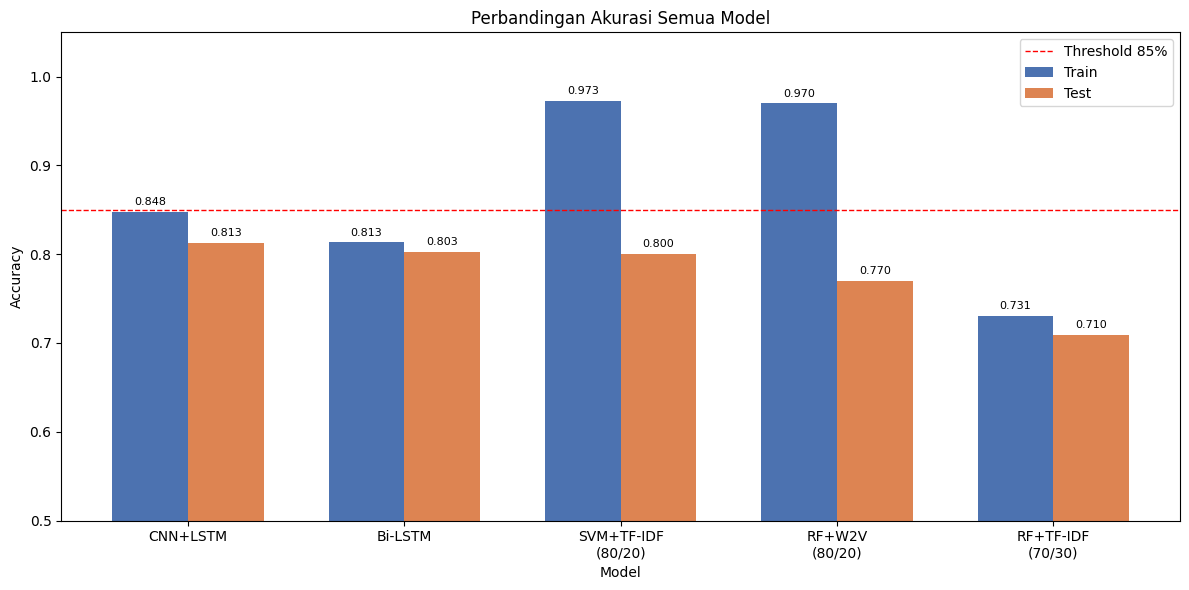

In [38]:
models  = ['CNN+LSTM', 'Bi-LSTM', 'SVM+TF-IDF\n(80/20)', 'RF+W2V\n(80/20)', 'RF+TF-IDF\n(70/30)']
train_a = [train_acc_cnn, train_acc_rnn, acc_train_s1, acc_train_s2, acc_train_s3]
test_a  = [test_acc_cnn,  test_acc_rnn,  acc_test_s1,  acc_test_s2,  acc_test_s3]

x = np.arange(len(models))
w = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
b1 = ax.bar(x - w/2, train_a, w, label='Train', color='#4C72B0')
b2 = ax.bar(x + w/2, test_a,  w, label='Test',  color='#DD8452')

ax.set_xlabel('Model')
ax.set_ylabel('Accuracy')
ax.set_title('Perbandingan Akurasi Semua Model')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0.5, 1.05)
ax.axhline(0.85, color='red', linestyle='--', linewidth=1, label='Threshold 85%')
ax.legend()

for bar in b1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
for bar in b2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

### Simpan Tokenizer & Objek Pendukung

In [39]:
import pickle
import joblib

# Tokenizer Keras (untuk CNN+LSTM & Bi-LSTM)
with open('tokenizer_dl.pkl', 'wb') as f:
    pickle.dump(tokenizer_dl, f)

# SVM + TF-IDF
joblib.dump(svm_s1,     'model_svm.pkl')
joblib.dump(tfidf_s1,   'tfidf_s1.pkl')

# RF + Word2Vec
joblib.dump(rf_s2,      'model_rf_w2v.pkl')
joblib.dump(scaler_s2,  'scaler_s2.pkl')
w2v.save('model_w2v.model')

# RF + TF-IDF
joblib.dump(rf_s3,      'model_rf_tfidf.pkl')
joblib.dump(tfidf_s3,   'tfidf_s3.pkl')
joblib.dump(scaler_s3,  'scaler_s3.pkl')

print('Semua model dan objek pendukung berhasil disimpan.')

Semua model dan objek pendukung berhasil disimpan.


In [40]:
!pip freeze requirements.txt

absl-py==1.4.0
accelerate==1.13.0
access==1.1.10.post3
affine==2.4.0
aiofiles==24.1.0
aiohappyeyeballs==2.6.1
aiohttp==3.13.5
aiosignal==1.4.0
aiosqlite==0.22.1
alabaster==1.0.0
albucore==0.0.24
albumentations==2.0.8
ale-py==0.11.2
alembic==1.18.4
altair==5.5.0
annotated-doc==0.0.4
annotated-types==0.7.0
antlr4-python3-runtime==4.9.3
anyio==4.13.0
anywidget==0.9.21
apsw==3.53.0.0
apswutils==0.1.2
argon2-cffi==25.1.0
argon2-cffi-bindings==25.1.0
array_record==0.8.3
arrow==1.4.0
arviz==0.22.0
astropy==7.2.0
astropy-iers-data==0.2026.4.6.0.54.57
astunparse==1.6.3
atpublic==5.1
attrs==26.1.0
audioread==3.1.0
Authlib==1.6.9
autograd==1.8.0
babel==2.18.0
backcall==0.2.0
beartype==0.22.9
beautifulsoup4==4.13.5
betterproto==2.0.0b6
bigframes==2.39.0
bigquery-magics==0.12.2
bleach==6.3.0
blinker==1.9.0
blis==1.3.3
blobfile==3.2.0
blosc2==4.1.2
bokeh==3.8.2
Bottleneck==1.4.2
bqplot==0.12.45
branca==0.8.2
brotli==1.2.0
CacheControl==0.14.4
cachetools==6.2.6
catalogue==2.0.10
certifi==2026.2.25
cf